# 1. Project Introduction

## PRCP-1002 Handwritten Digits Recognition

The objective of this project is to analyze the MNIST handwritten digit
dataset and develop machine learning classification models capable of
recognizing handwritten digits from 0 to 9.

The project includes exploratory data analysis, data preprocessing,
classification using multiple machine learning algorithms, model
comparison, evaluation of the best-performing model, and analysis of
challenges faced during the project.

# 2. Loading the MNIST Dataset

The MNIST dataset is a collection of handwritten digit images. Each image
represents one of the ten digits from 0 to 9.

The dataset is loaded using TensorFlow Keras.

In [1]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("MNIST dataset loaded successfully!")

MNIST dataset loaded successfully!


In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]

Python executable:
C:\Users\DELL\anaconda3\envs\handwritten\python.exe


# PRCP-1002 Handwritten Digits Recognition

## 1. Project Introduction

### Problem Statement

The objective of this project is to analyze the MNIST handwritten digit
dataset and develop machine learning classification models capable of
recognizing handwritten digits.

Each input is a handwritten digit image and the output belongs to one of
10 classes representing the digits 0 through 9.

The project includes:

- Exploratory data analysis
- Data preprocessing
- Visualization of handwritten digits
- Classification using multiple machine learning algorithms
- Model performance comparison
- Selection of the best-performing classifier
- Prediction of handwritten digits
- Analysis of challenges and techniques used to address them

### Dataset

The MNIST dataset contains grayscale images of handwritten digits.
Each image has dimensions of 28 × 28 pixels.

The dataset is divided into training and testing sets.

# 2. Import Required Libraries

In [2]:
# Numerical operations
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# MNIST dataset
from tensorflow.keras.datasets import mnist

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Time measurement
import time

print("All libraries imported successfully!")

All libraries imported successfully!


# 3. Loading the MNIST Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("MNIST dataset loaded successfully!")

print("\nTraining images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

MNIST dataset loaded successfully!

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## 3.1 Dataset Dimensions

In [4]:
print("Number of training images:", x_train.shape[0])
print("Number of test images:", x_test.shape[0])

print("Image height:", x_train.shape[1])
print("Image width:", x_train.shape[2])

print("Number of pixels per image:", x_train.shape[1] * x_train.shape[2])

print("Number of classes:", len(np.unique(y_train)))

Number of training images: 60000
Number of test images: 10000
Image height: 28
Image width: 28
Number of pixels per image: 784
Number of classes: 10


## 3.2 Target Classes

In [5]:
unique_digits = np.unique(y_train)

print("Unique digit classes:")
print(unique_digits)

Unique digit classes:
[0 1 2 3 4 5 6 7 8 9]


## 3.3 Distribution of Digits

In [6]:
unique, counts = np.unique(y_train, return_counts=True)

digit_distribution = pd.DataFrame({
    "Digit": unique,
    "Count": counts
})

digit_distribution

,Digit,Count
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


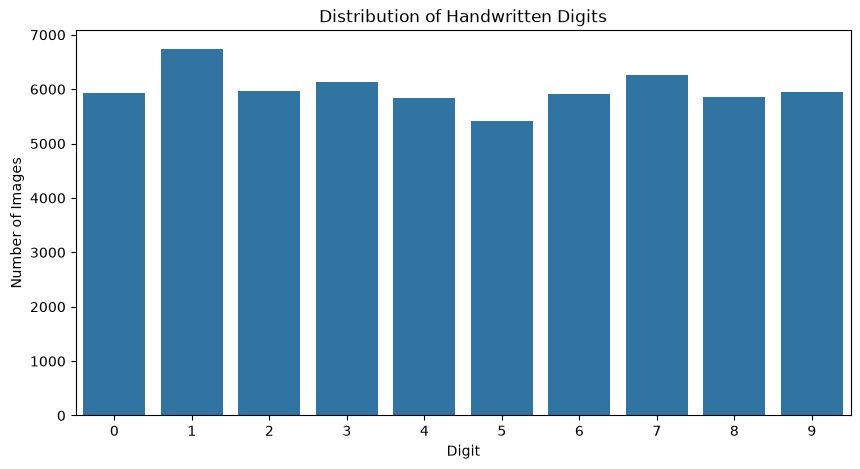

In [7]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=digit_distribution,
    x="Digit",
    y="Count"
)

plt.title("Distribution of Handwritten Digits")
plt.xlabel("Digit")
plt.ylabel("Number of Images")

plt.show()

# 4. Exploratory Data Analysis

## 4.1 Sample Handwritten Digits

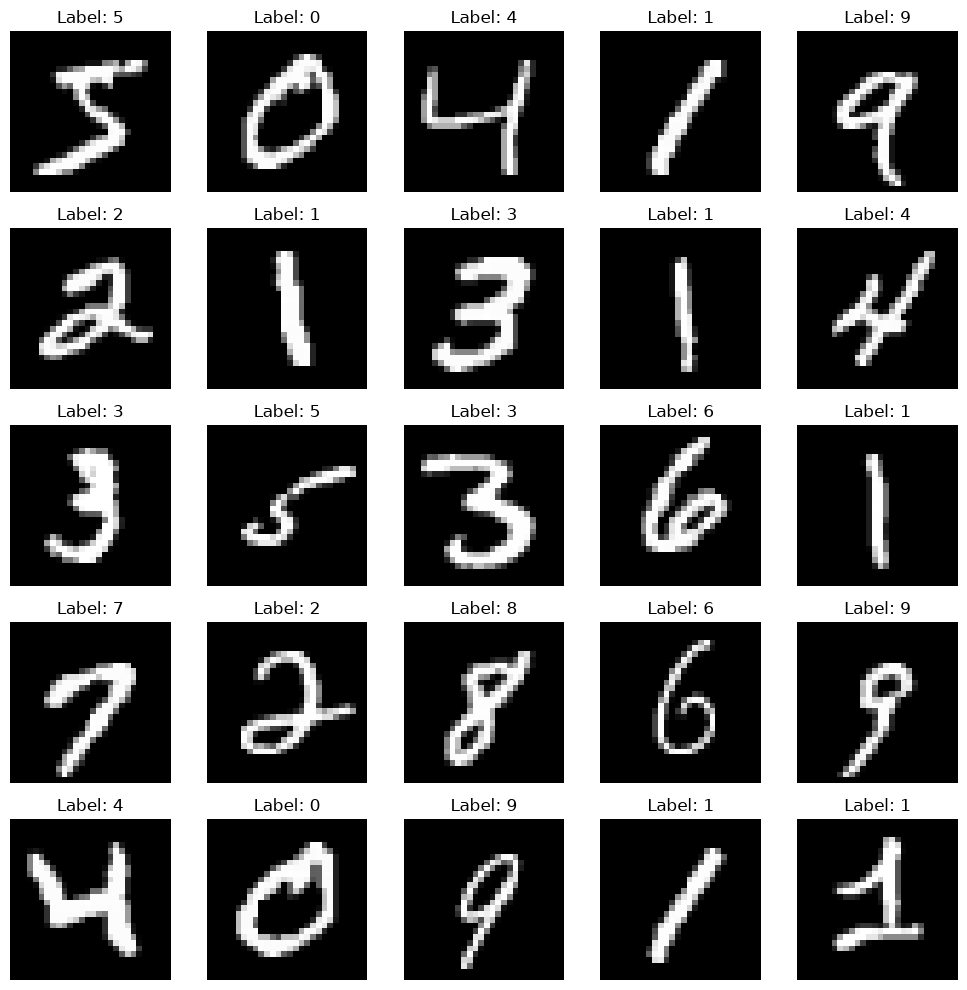

In [8]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

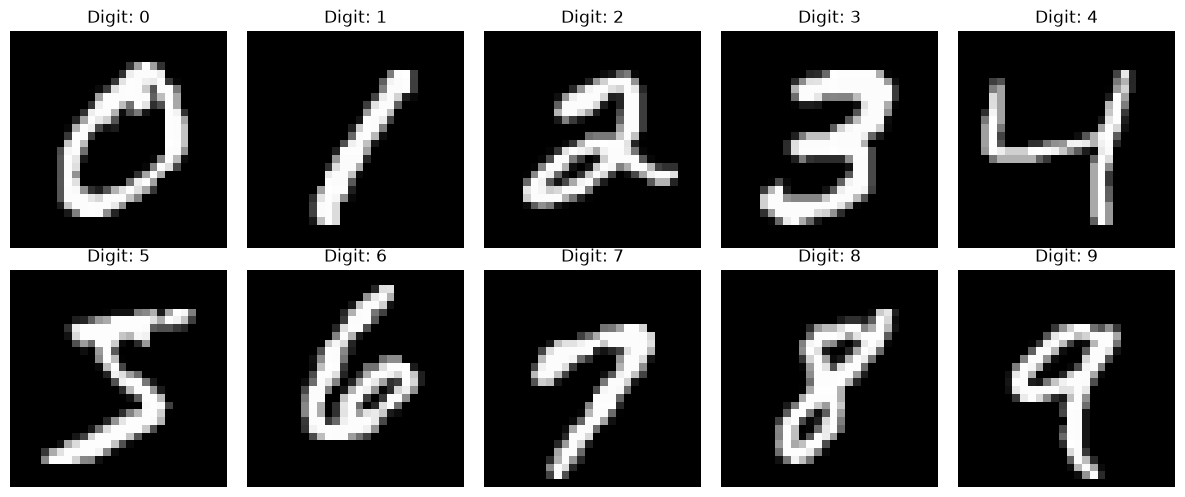

In [9]:
plt.figure(figsize=(12, 5))

for digit in range(10):
    index = np.where(y_train == digit)[0][0]
    
    plt.subplot(2, 5, digit + 1)
    plt.imshow(x_train[index], cmap="gray")
    plt.title(f"Digit: {digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4.2 Pixel Value Analysis

In [10]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

print("Image data type:", x_train.dtype)

Minimum pixel value: 0
Maximum pixel value: 255
Image data type: uint8


In [11]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [12]:
print("Missing values in training images:",
      np.isnan(x_train).sum())

print("Missing values in testing images:",
      np.isnan(x_test).sum())

Missing values in training images: 0
Missing values in testing images: 0


# 5. Data Preprocessing

## 5.1 Reshaping the Images

Each MNIST image has dimensions of 28 × 28 pixels.

For traditional machine learning algorithms, each image is converted into
a one-dimensional vector containing 784 pixel values.

In [13]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print("Original training shape:", x_train.shape)
print("Reshaped training shape:", x_train_flat.shape)

print("Original testing shape:", x_test.shape)
print("Reshaped testing shape:", x_test_flat.shape)

Original training shape: (60000, 28, 28)
Reshaped training shape: (60000, 784)
Original testing shape: (10000, 28, 28)
Reshaped testing shape: (10000, 784)


## 5.2 Pixel Normalization

The original pixel values range from 0 to 255.

The values are normalized to the range 0 to 1 by dividing by 255.
This makes the numerical scale smaller and is useful for machine learning
algorithms.

In [14]:
x_train_scaled = x_train_flat.astype("float32") / 255.0
x_test_scaled = x_test_flat.astype("float32") / 255.0

print("Minimum scaled value:", x_train_scaled.min())
print("Maximum scaled value:", x_train_scaled.max())

Minimum scaled value: 0.0
Maximum scaled value: 1.0


In [15]:
print("Training data shape:", x_train_scaled.shape)
print("Testing data shape:", x_test_scaled.shape)

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 784)
Testing data shape: (10000, 784)
Training labels shape: (60000,)
Testing labels shape: (10000,)


In [16]:
X_model, _, y_model, _ = train_test_split(
    x_train_scaled,
    y_train,
    train_size=15000,
    stratify=y_train,
    random_state=42
)

print("Model training data:", X_model.shape)
print("Model training labels:", y_model.shape)

Model training data: (15000, 784)
Model training labels: (15000,)


# 6. Model 1 — K-Nearest Neighbors

K-Nearest Neighbors (KNN) classifies an observation based on the labels of
nearby observations.

We will train a KNN classifier and evaluate its accuracy on the test set.

In [17]:
knn = KNeighborsClassifier(n_neighbors=3)

start_time = time.time()

knn.fit(X_model, y_model)

knn_training_time = time.time() - start_time

print("KNN training completed.")
print("Training time:", round(knn_training_time, 2), "seconds")

KNN training completed.
Training time: 0.01 seconds


In [18]:
start_time = time.time()

y_pred_knn = knn.predict(x_test_scaled)

knn_prediction_time = time.time() - start_time

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", round(knn_accuracy, 4))
print("KNN Prediction Time:", round(knn_prediction_time, 2), "seconds")

KNN Accuracy: 0.9529
KNN Prediction Time: 9.94 seconds


In [19]:
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.92      1.00      0.96      1135
           2       0.97      0.92      0.95      1032
           3       0.93      0.95      0.94      1010
           4       0.96      0.94      0.95       982
           5       0.96      0.94      0.95       892
           6       0.97      0.98      0.98       958
           7       0.95      0.95      0.95      1028
           8       0.98      0.91      0.94       974
           9       0.94      0.94      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



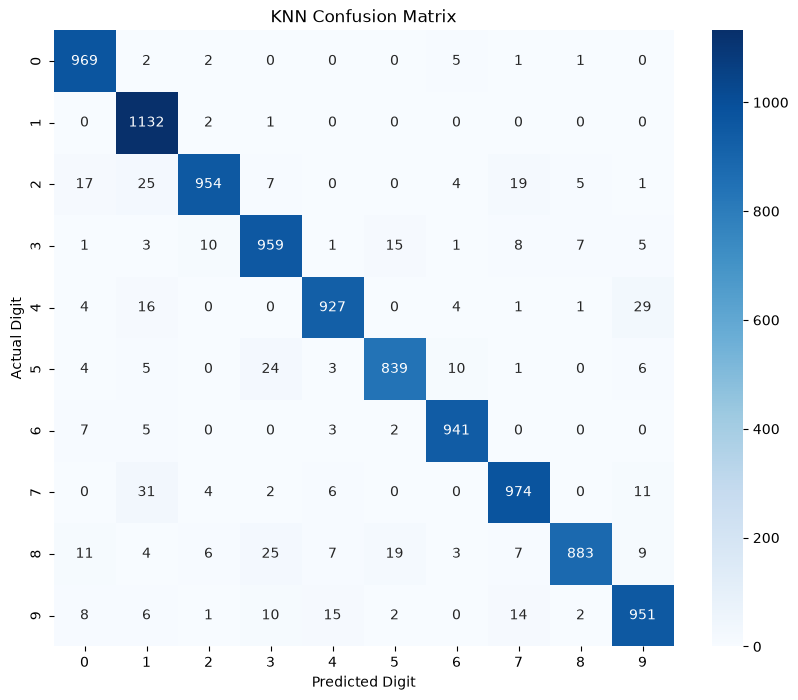

In [20]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.show()

# 7. Model 2 — Support Vector Machine

Support Vector Machine (SVM) is a classification algorithm that attempts
to find decision boundaries that separate different classes.

SVM is particularly useful for high-dimensional classification problems.

In [21]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

start_time = time.time()

svm_model.fit(X_model, y_model)

svm_training_time = time.time() - start_time

print("SVM training completed.")
print("Training time:", round(svm_training_time, 2), "seconds")

SVM training completed.
Training time: 34.75 seconds


In [22]:
start_time = time.time()

y_pred_svm = svm_model.predict(x_test_scaled)

svm_prediction_time = time.time() - start_time

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(svm_accuracy, 4))
print("SVM Prediction Time:", round(svm_prediction_time, 2), "seconds")

SVM Accuracy: 0.9729
SVM Prediction Time: 51.27 seconds


In [23]:
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.96      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



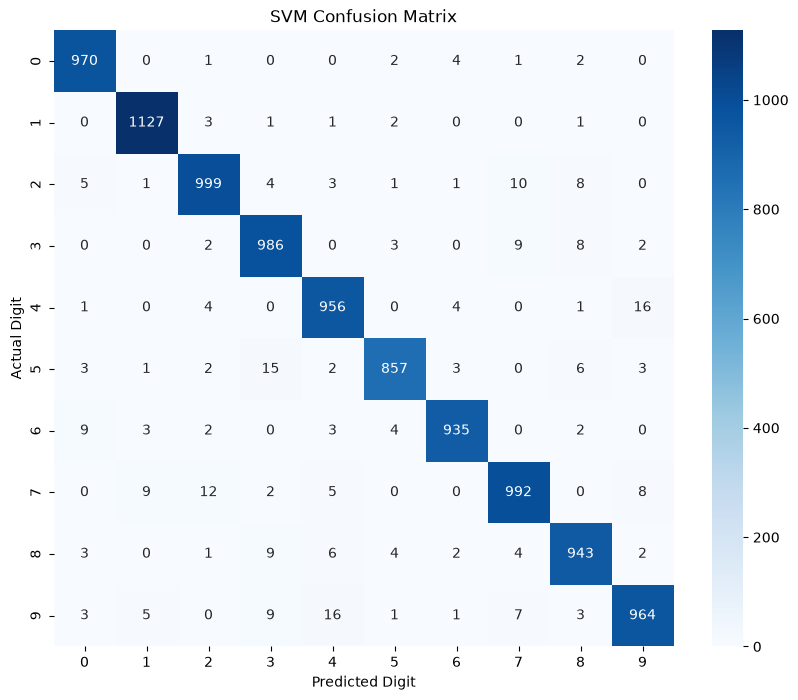

In [24]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.show()

# 8. Model 3 — Neural Network

A multilayer perceptron neural network is used as a third classification
approach.

The network learns nonlinear relationships between the 784 pixel features
and the ten digit classes.

In [25]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="adam",
    batch_size=128,
    max_iter=20,
    random_state=42,
    verbose=True
)

start_time = time.time()

mlp_model.fit(X_model, y_model)

mlp_training_time = time.time() - start_time

print("Neural Network training completed.")
print("Training time:", round(mlp_training_time, 2), "seconds")

Iteration 1, loss = 0.66760409
Iteration 2, loss = 0.29653462
Iteration 3, loss = 0.23579918
Iteration 4, loss = 0.19753284
Iteration 5, loss = 0.16924541
Iteration 6, loss = 0.14636589
Iteration 7, loss = 0.12309716
Iteration 8, loss = 0.10828063
Iteration 9, loss = 0.09521819
Iteration 10, loss = 0.08310520
Iteration 11, loss = 0.07151882
Iteration 12, loss = 0.06500892
Iteration 13, loss = 0.05654025
Iteration 14, loss = 0.04904366
Iteration 15, loss = 0.04368468
Iteration 16, loss = 0.03875665
Iteration 17, loss = 0.03318946
Iteration 18, loss = 0.03013394
Iteration 19, loss = 0.02606072
Iteration 20, loss = 0.02251034
Neural Network training completed.
Training time: 12.37 seconds


C:\Users\DELL\anaconda3\envs\handwritten\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [26]:
start_time = time.time()

y_pred_mlp = mlp_model.predict(x_test_scaled)

mlp_prediction_time = time.time() - start_time

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

print("Neural Network Accuracy:", round(mlp_accuracy, 4))
print(
    "Neural Network Prediction Time:",
    round(mlp_prediction_time, 2),
    "seconds"
)

Neural Network Accuracy: 0.9599
Neural Network Prediction Time: 0.03 seconds


In [27]:
print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_mlp))

Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.95      0.96      1032
           3       0.95      0.96      0.95      1010
           4       0.96      0.96      0.96       982
           5       0.96      0.95      0.96       892
           6       0.96      0.97      0.96       958
           7       0.95      0.96      0.96      1028
           8       0.96      0.92      0.94       974
           9       0.95      0.96      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



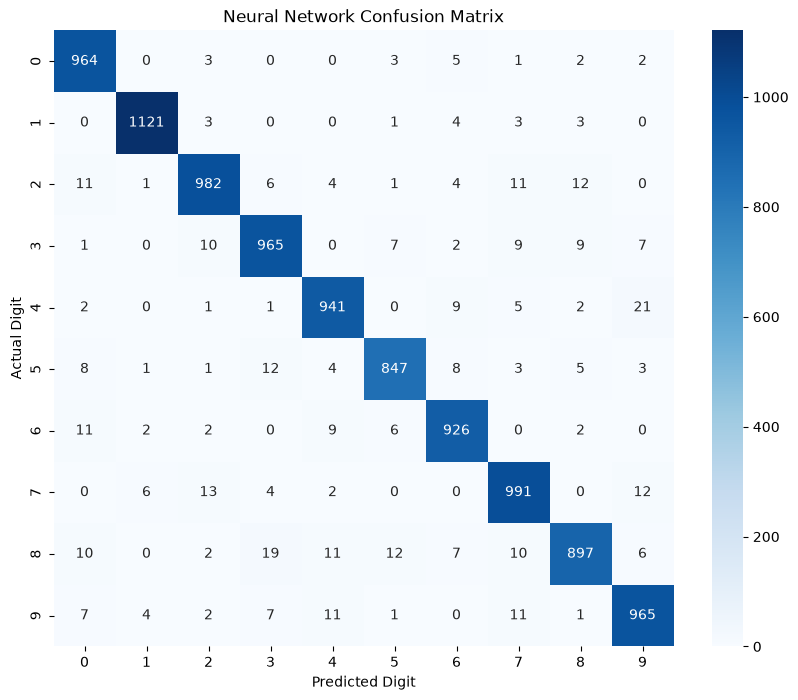

In [28]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.show()

# 9. Model Comparison

In [29]:
model_comparison = pd.DataFrame({
    "Model": [
        "KNN",
        "SVM",
        "Neural Network"
    ],
    "Accuracy": [
        knn_accuracy,
        svm_accuracy,
        mlp_accuracy
    ],
    "Training Time (seconds)": [
        knn_training_time,
        svm_training_time,
        mlp_training_time
    ],
    "Prediction Time (seconds)": [
        knn_prediction_time,
        svm_prediction_time,
        mlp_prediction_time
    ]
})

model_comparison

,Model,Accuracy,Training Time (seconds),Prediction Time (seconds)
0,KNN,0.9529,0.013209,9.941044
1,SVM,0.9729,34.747842,51.268100
2,Neural Network,0.9599,12.366048,0.032358


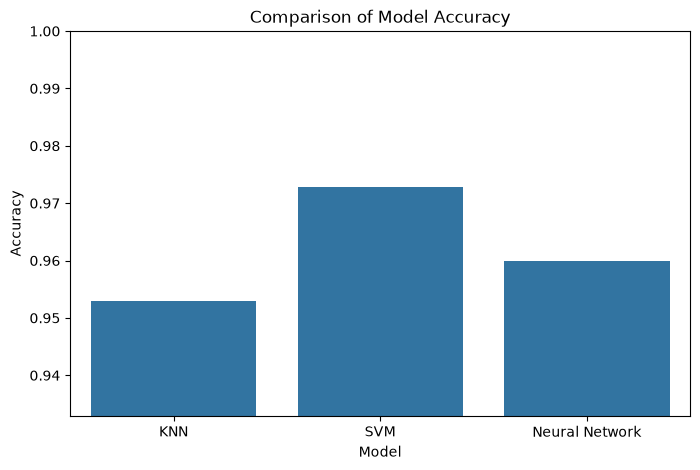

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Comparison of Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(
    max(0, model_comparison["Accuracy"].min() - 0.02),
    1.0
)

plt.show()

In [31]:
best_model_row = model_comparison.loc[
    model_comparison["Accuracy"].idxmax()
]

print("Best Model:")
print(best_model_row)

Best Model:
Model                              SVM
Accuracy                        0.9729
Training Time (seconds)      34.747842
Prediction Time (seconds)      51.2681
Name: 1, dtype: object


In [32]:
best_model_name = best_model_row["Model"]

if best_model_name == "KNN":
    best_predictions = y_pred_knn

elif best_model_name == "SVM":
    best_predictions = y_pred_svm

else:
    best_predictions = y_pred_mlp

print("Best model:", best_model_name)

print("\nClassification Report:")
print(classification_report(y_test, best_predictions))

Best model: SVM

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.96      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



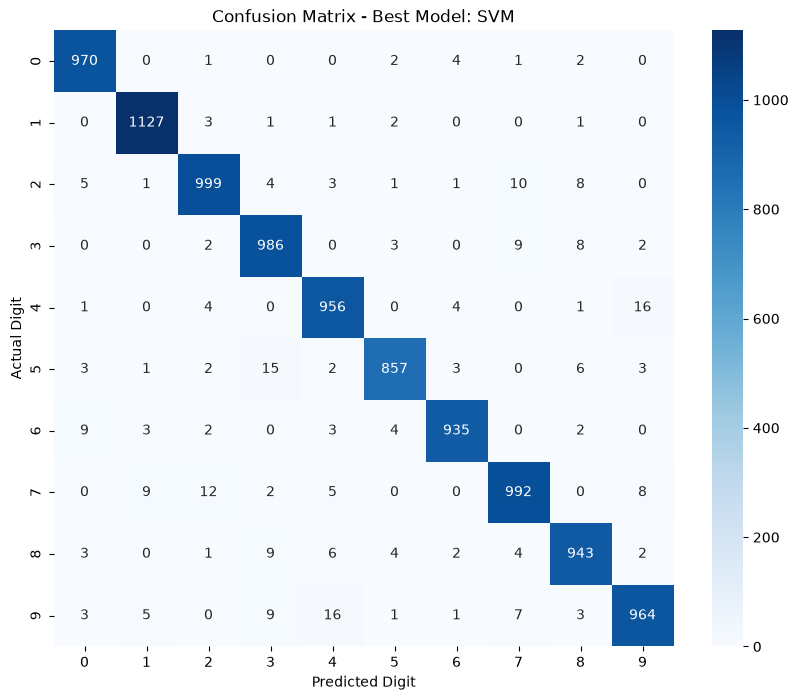

In [33]:
best_cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - Best Model: {best_model_name}")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.show()

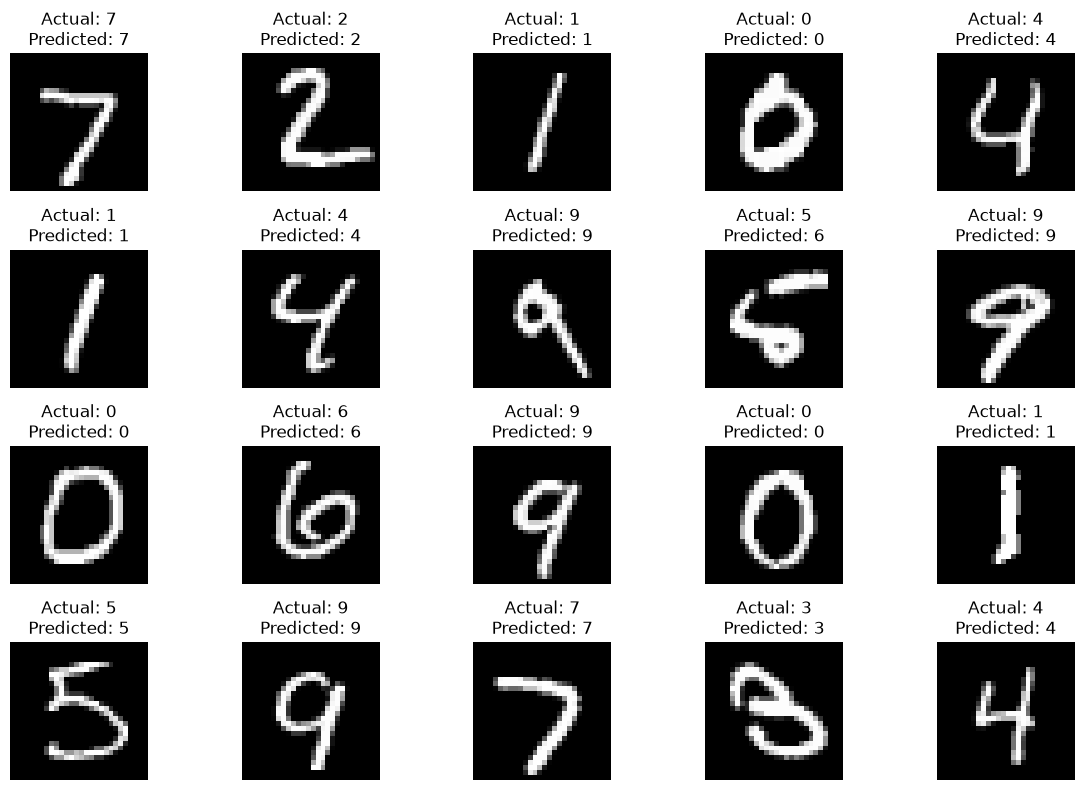

In [34]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(x_test[i], cmap="gray")
    
    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {best_predictions[i]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
incorrect_indices = np.where(
    best_predictions != y_test
)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 271


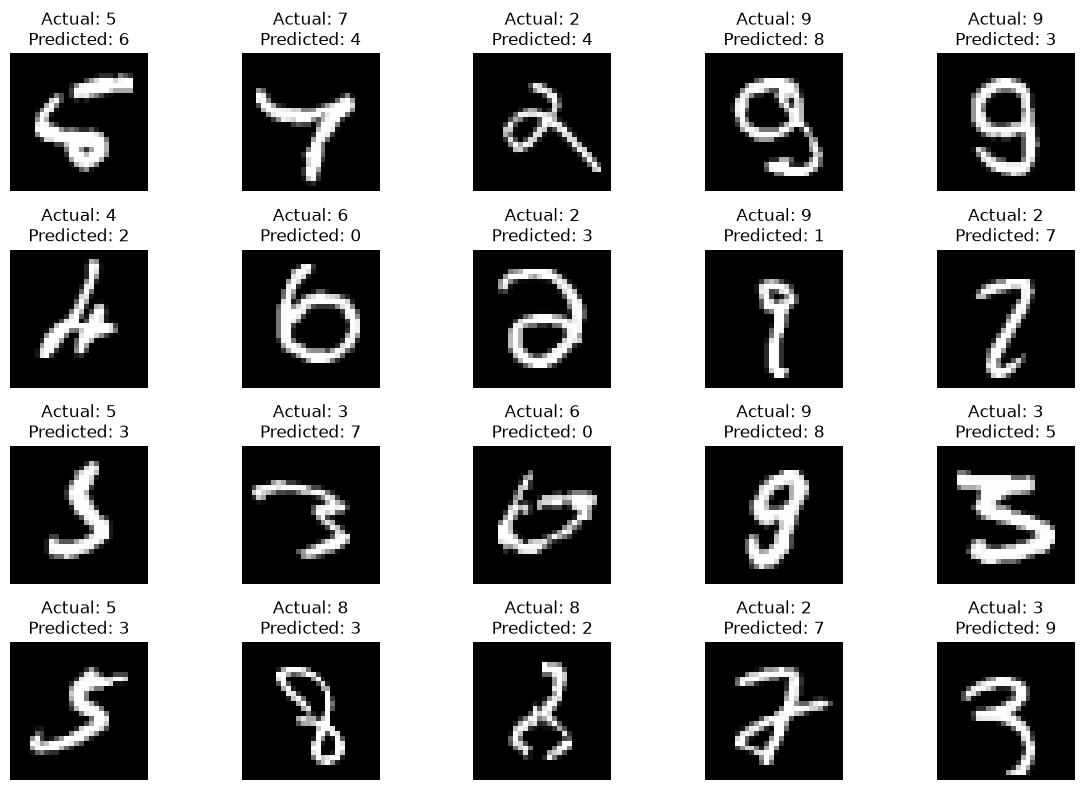

In [36]:
plt.figure(figsize=(12, 8))

for i in range(min(20, len(incorrect_indices))):
    index = incorrect_indices[i]
    
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(x_test[index], cmap="gray")
    
    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {best_predictions[index]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

# 10. Challenges Faced and Techniques Used

## Challenge 1: Image Representation

The original MNIST images are stored as 28 × 28 pixel matrices.
Traditional machine learning algorithms require numerical feature
vectors, so the images were reshaped into vectors containing 784 features.

### Technique Used

Each 28 × 28 image was flattened into a one-dimensional vector of 784
pixel values.

---

## Challenge 2: Pixel Scale

The original pixel values range from 0 to 255.

### Technique Used

The pixel values were normalized by dividing by 255 so that the values
were represented between 0 and 1.

---

## Challenge 3: Computational Cost

Some machine learning algorithms, especially SVM and KNN, can require
significant computational resources when applied to the complete
training dataset.

### Technique Used

A stratified subset of the training data was used for the initial model
comparison while the official test set was kept separate for evaluation.

---

## Challenge 4: Similar Handwritten Digits

Some handwritten digits have similar shapes, making them difficult for
classifiers to distinguish.

### Technique Used

Confusion matrices and classification reports were used to identify
which digit classes were more difficult to classify.

---

## Challenge 5: Model Selection

Different classification algorithms can have different accuracy,
training times, and prediction times.

### Technique Used

KNN, SVM, and a neural network were trained and compared using accuracy,
training time, and prediction time.